# Fraud_Credit_Card

## Exploratory Data Analysis (EDA)

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [121]:
# Load the data

df = pd.read_csv("C:/Users/eitank/personal/Projects/Fraud_Credit_Card/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

No categorical/string columns are included (Only the target variable is categorical). No NULL values. All columns except for Time and Amount are transformed by PCA and have been Scaled.

In [123]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


492 Of Frauds 0.17%
284315 No Frauds 99.83%


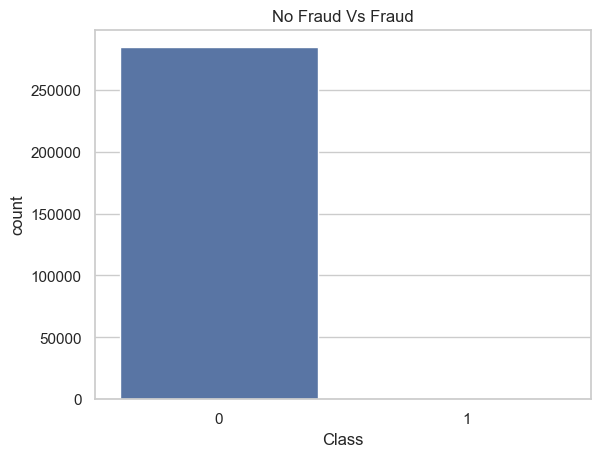

In [124]:
fraud=len(df[df["Class"]==1])
no_fraud=len(df[df["Class"]==0])
total =len(df)
print(f"{fraud} Of Frauds {round(fraud/total* 100,2)}%")
print(f"{no_fraud} No Frauds {round(no_fraud/total* 100,2)}%")
sns.countplot(data=df,x="Class")
plt.title("No Fraud Vs Fraud")
plt.show()

As we can see, there is only 0.17% fraud , which is a severe imbalance. 

In [125]:
# from pandas_profiling import ProfileReport
# design_report = ProfileReport(df)
# design_report.to_file(output_file='credit_card.html')

In [126]:
# import sweetviz as sv
# sweet_report = sv.analyze(df)
# sweet_report.show_html('credit_card_sr.html')

Heatmap to Visualize the Correlation Between Numerical Features

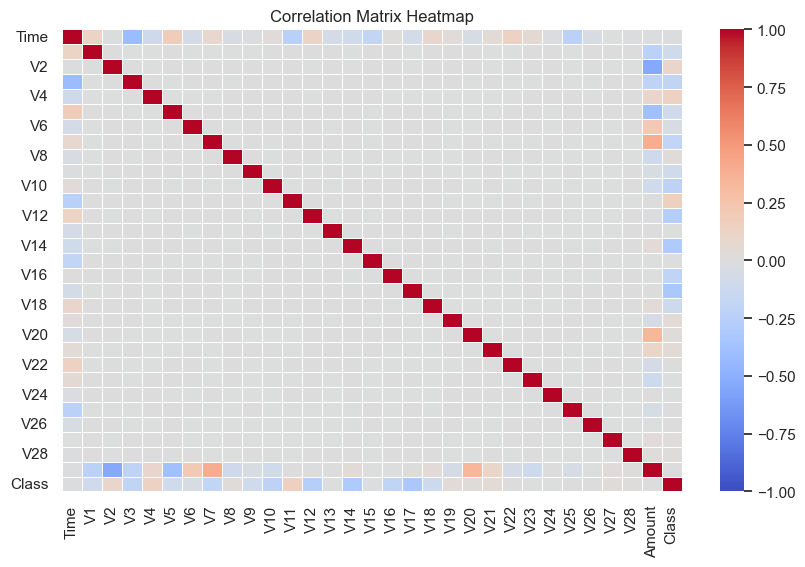

In [127]:
correlation_matrix=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,cmap='coolwarm',vmin=-1,vmax=1,annot=False,linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Interaction with other variables (Non- traget variable):

Baded on reports and the above heatmap there is no notable correlation between features V1-V28. 

There are certain correlations for the feature Time:
- **Inverse correlation with V3**: As Time increases, the value of V3 tends to decrease.

For the Amount feature:
- **Direct correlation with V7, V6, and V20**: Higher transaction amounts are associated with higher values in V7, V6, and V20.
- **Inverse correlation with V2 and V5**: Higher transaction amounts are associated with lower values in V2 and V5.

### Feature Engineering

The hour with the most frequent fraud is: 2.0:00
Number of fraud during this hour: 57


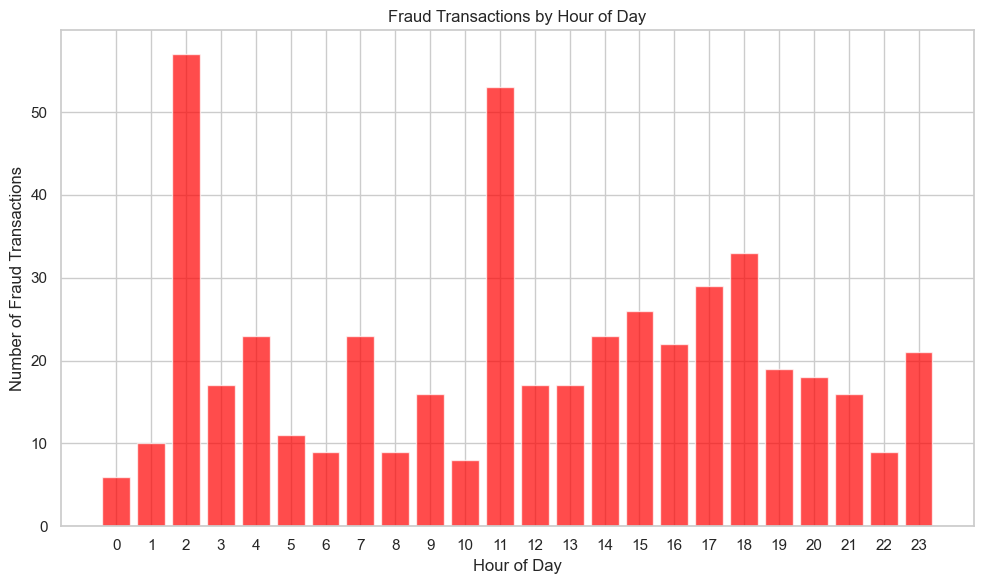

In [128]:
# Convert the 'Time' column to hours
df['hour_of_day'] = (df['Time'] // 3600) % 24

# Assuming 'Class' column indicates fraud transactions (1 for fraud, 0 for non-fraud)
df['is_fraud'] = df['Class']

# Separate the fraud transactions
fraud_df = df[df['is_fraud'] == 1]

# Aggregate by hour for fraud transactions
fraud_by_hour = fraud_df.groupby('hour_of_day').size()

# Find the hour with the most frequent fraud transactions
most_frequent_hour = fraud_by_hour.idxmax()
most_frequent_count = fraud_by_hour.max()

# Print the result
print(f"The hour with the most frequent fraud is: {most_frequent_hour}:00")
print(f"Number of fraud during this hour: {most_frequent_count}")

# Plotting the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
plt.bar(fraud_by_hour.index, fraud_by_hour.values, color='red', alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraud Transactions')
plt.title('Fraud Transactions by Hour of Day')
plt.xticks(range(0, 24))  # Set x-ticks for hours
plt.tight_layout()
plt.show()


The above bar plot visually represents the distribution of fraudulent transactions by hour of the day. The peak at 2:00 AM indicates the highest frequency of fraudulent activities during this time.This analysis highlights the importance of monitoring specific hours of the day for potential fraudulent activities. By focusing on peak hours, such as 2:00 AM, institutions can enhance their fraud detection mechanisms and prevent potential losses.

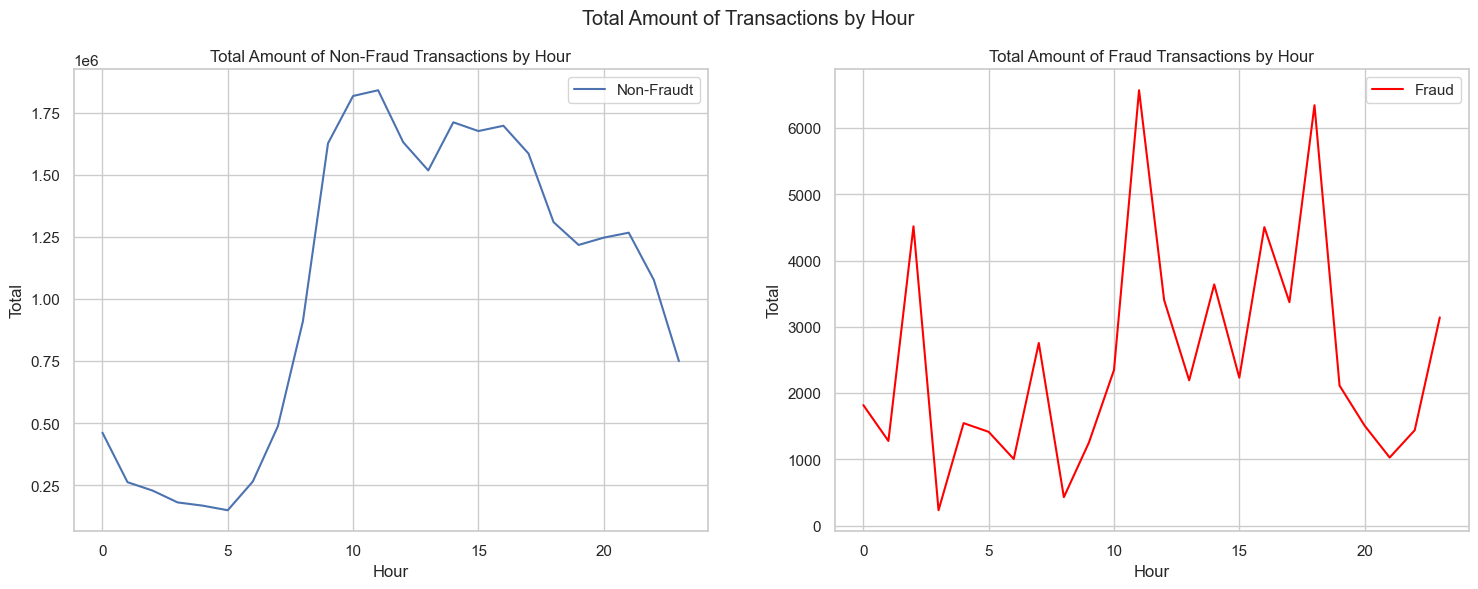

In [129]:
# Separate fraudulent and non-fraudulent transactions
fraudulent_df = df[df['Class'] == 1]
non_fraudulent_df = df[df['Class'] == 0]

# Calculate required statistics for fraudulent transactions
fraudulent_stats = fraudulent_df.groupby('hour_of_day').agg({
    'Amount': ['sum', 'mean', 'min', 'max', 'median']
}).reset_index()
fraudulent_stats.columns = ['Hour', 'Total', 'Mean', 'Min', 'Max', 'Median']

# Calculate required statistics for non-fraudulent transactions
non_fraudulent_stats = non_fraudulent_df.groupby('hour_of_day').agg({
    'Amount': ['sum', 'mean', 'min', 'max', 'median']
}).reset_index()
non_fraudulent_stats.columns = ['Hour', 'Total', 'Mean', 'Min', 'Max', 'Median']
# Set up the plotting environment
sns.set(style="whitegrid")

# Plot Total Amount
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))
sns.lineplot(ax=ax1, x='Hour', y='Total', data=non_fraudulent_stats, label='Non-Fraudt')
sns.lineplot(ax=ax2, x='Hour', y='Total', data=fraudulent_stats, label='Fraud', color='red')
ax1.set_title('Total Amount of Non-Fraud Transactions by Hour')
ax2.set_title('Total Amount of Fraud Transactions by Hour')
plt.suptitle('Total Amount of Transactions by Hour')
plt.show()
df=df.drop(columns=['is_fraud','hour_of_day'])


In this section, we visualize Total of transaction amounts by the hour for both fraudulent and non-fraudulent transactions. This helps us understand the temporal patterns and differences between fraudulent and non-fraudulent transactions.

### Remove Duplicate

In [102]:
# Duplicating Data (Number of Columns)

print(f"Non-Frauds: {df[df.Class == 0].duplicated().sum()}")
print(f"Frauds: {df[df.Class == 1].duplicated().sum()}")
print("*" * 100)

# Drop
df.drop_duplicates(inplace=True)
print("Dropped Succesfully")
print("*" * 100)

# Check
print(f"Non-Frauds: {df[df.Class == 0].duplicated().sum()}")
print(f"Frauds: {df[df.Class == 1].duplicated().sum()}")

Non-Frauds: 1062
Frauds: 19
****************************************************************************************************
Dropped Succesfully
****************************************************************************************************
Non-Frauds: 0
Frauds: 0


Check again the percentage between Fraud and non

473 Of Frauds 0.17%
283253 No Frauds 99.83%


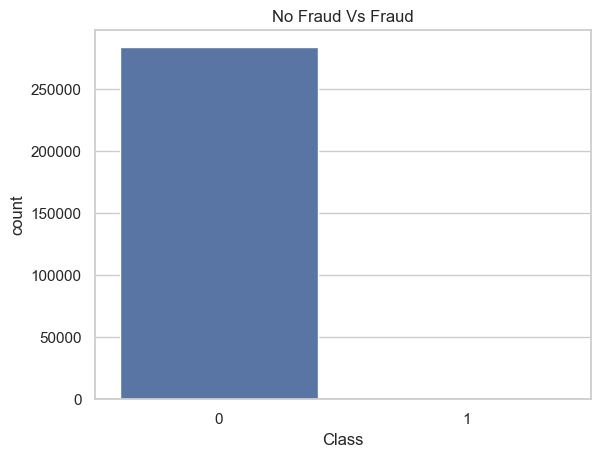

In [103]:
fraud=len(df[df["Class"]==1])
no_fraud=len(df[df["Class"]==0])
total =len(df)
print(f"{fraud} Of Frauds {round(fraud/total* 100,2)}%")
print(f"{no_fraud} No Frauds {round(no_fraud/total* 100,2)}%")
sns.countplot(data=df,x="Class")
plt.title("No Fraud Vs Fraud")
plt.show()

Missing- None.

Outliers -  I'll not deal with them. Becuase all is possible. The amount for example could be easily over 5k.

📌 Columns with outliers and the number of outliers in each:
V1: 7062 outliers
V2: 13526 outliers
V3: 3363 outliers
V4: 11148 outliers
V5: 12295 outliers
V6: 22965 outliers
V7: 8948 outliers
V8: 24134 outliers
V9: 8283 outliers
V10: 9496 outliers
V11: 780 outliers
V12: 15348 outliers
V13: 3368 outliers
V14: 14149 outliers
V15: 2894 outliers
V16: 8184 outliers
V17: 7420 outliers
V18: 7533 outliers
V19: 10205 outliers
V20: 27770 outliers
V21: 14497 outliers
V22: 1317 outliers
V23: 18541 outliers
V24: 4774 outliers
V25: 5367 outliers
V26: 5596 outliers
V27: 39163 outliers
V28: 30342 outliers
Amount: 31904 outliers
Class: 492 outliers


C:\Users\eitank\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


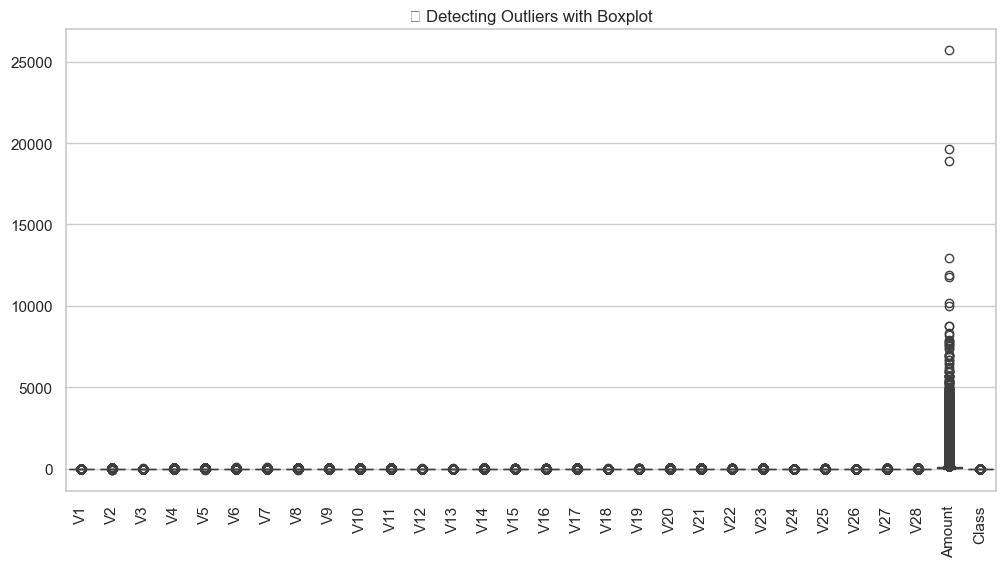

In [130]:
#outliers

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Detect outliers in each numerical column using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers.shape[0]

# 2️⃣ Check for outliers in all numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
outlier_counts = {col: detect_outliers(df, col) for col in num_cols}

# 3️⃣ Print columns with outliers and their count
outlier_cols = {col: count for col, count in outlier_counts.items() if count > 0}
print("📌 Columns with outliers and the number of outliers in each:")
for col, count in outlier_cols.items():
    print(f"{col}: {count} outliers")

# 4️⃣ Display Boxplot for all columns with outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[list(outlier_cols.keys())])
plt.xticks(rotation=90)
plt.title("🔍 Detecting Outliers with Boxplot")
plt.show()


### Imbalance Data



Class imbalance in fraud detection datasets, where fraudulent transactions are significantly fewer than non-fraudulent ones, leads to several challenges:

1. **Biased Model Performance**: Models tend to favor the majority class, resulting in poor fraud detection.
2. **Misleading Accuracy**: High accuracy may be deceptive as it could reflect the model's bias towards non-fraudulent transactions.
3. **Poor Recall and Precision**: Low recall (high false negatives) and precision (high false positives) for fraud detection.
4. **Evaluation Metrics**: Standard metrics like accuracy are inadequate; precision, recall, F1-score, and AUC-ROC are more suitable.
5. **Training Instability**: Models may overfit the majority class due to imbalance.

Methods to address these challenges include:

- **Resampling Techniques**: Use oversampling (e.g., SMOTE) or undersampling.
- **Class Weight Adjustment**: Adjust class weights in the loss function.
- **Anomaly Detection Models**: Use models designed for anomaly detection.
- **Ensemble Methods**: Use robust methods like Random Forest and Gradient Boosting.
- **Evaluation Metrics**: Focus on precision, recall, F1-score, and AUC-ROC.

These methods improve the model's ability to detect fraudulent transactions and mitigate the impact of class imbalance.


Class distribution after resampling:
Counter({0: 283253, 1: 283253})


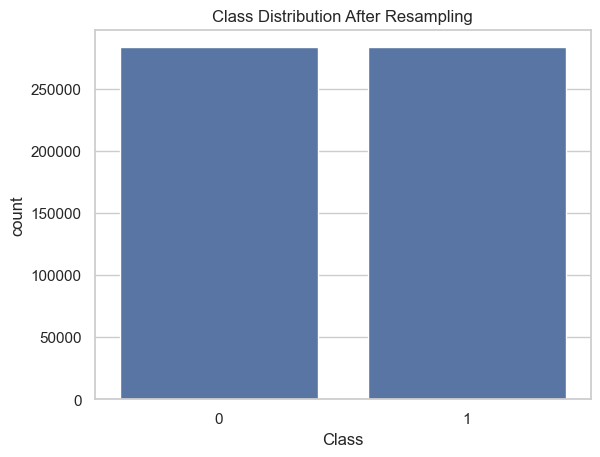

In [105]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Separate input features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert resampled data back to a DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Class'] = y_resampled

# Display the class distribution after resampling
print("Class distribution after resampling:")
print(Counter(df_resampled['Class']))

# Plot the class distribution after resampling
sns.countplot(data=df_resampled, x='Class')
plt.title("Class Distribution After Resampling")
plt.show()

### Scale

In this step, we applied standard scaling to the features to normalize the data. This ensures that all features have a mean of 0 and a standard deviation of 1, to perform optimally.

In [106]:
from sklearn.preprocessing import StandardScaler

# Feature scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_resampled.drop(columns=['Class']))

### Split train and test

In [107]:
from sklearn.model_selection import train_test_split

# Splitting the data into Train, Validation, and Test sets

# First, split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Now, split Train (80%) further into Train (80% of 80% = 64%) and Validation (20% of 80% = 16%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Convert target variables to NumPy arrays for consistency
y_test = y_test.values 
y_train = y_train.values  

print(f"Training Data: {X_train.shape}, Validation Data: {X_val.shape}, Testing Data: {X_test.shape}")

Training Data: (362563, 30), Validation Data: (90641, 30), Testing Data: (113302, 30)


### Models

Based on the characteristics of the dataset and the classification challenge, the model selections can be justified as follows:

1. **Logistic Regression**:
    - **Simplicity**: Logistic Regression is a simple and interpretable model, which makes it a good starting point for binary classification tasks.
    - **Baseline Performance**: It provides a baseline performance metric to compare with more complex models.
    - **Linearity**: It assumes a linear relationship between the features and the log-odds of the target variable, which can be a reasonable assumption for some datasets.

2. **Random Forest**:
    - **Handling Imbalanced Data**: Random Forest is robust to imbalanced datasets, which is crucial given the severe class imbalance in the fraud detection dataset.
    - **Feature Importance**: It provides insights into feature importance, helping to understand which features contribute most to the prediction.
    - **Non-Linearity**: It can capture non-linear relationships between features and the target variable, which is often the case in real-world datasets.
    - **Ensemble Method**: As an ensemble method, it reduces the risk of overfitting compared to individual decision trees.

3. **Gradient Boosting**:
    - **High Performance**: Gradient Boosting often achieves high performance on a variety of datasets, including those with complex patterns.
    - **Handling Imbalanced Data**: Like Random Forest, Gradient Boosting can handle imbalanced datasets effectively.
    - **Non-Linearity**: It captures non-linear relationships and interactions between features.
    - **Boosting Technique**: It builds models sequentially, with each new model correcting errors made by the previous ones, leading to improved accuracy.

Given the severe class imbalance in the dataset (with only 0.17% fraud cases), it is essential to use models that can handle such imbalance effectively. Both Random Forest and Gradient Boosting are well-suited for this task. 

    accuracy = (True Positives + True Negatives) / (Total Instances)

    precision = True Positives / (True Positives + False Positives)

    recall = True Positives / (True Positives + False Negatives)

    f1 = 2 * (precision * recall) / (precision + recall)

preformance on validation set
Accuracy: 0.9780
Precision: 0.9903
Recall: 0.9654
F1 Score: 0.9777
preformance on test set
Accuracy: 0.9785
Precision: 0.9903
Recall: 0.9665
F1 Score: 0.9783


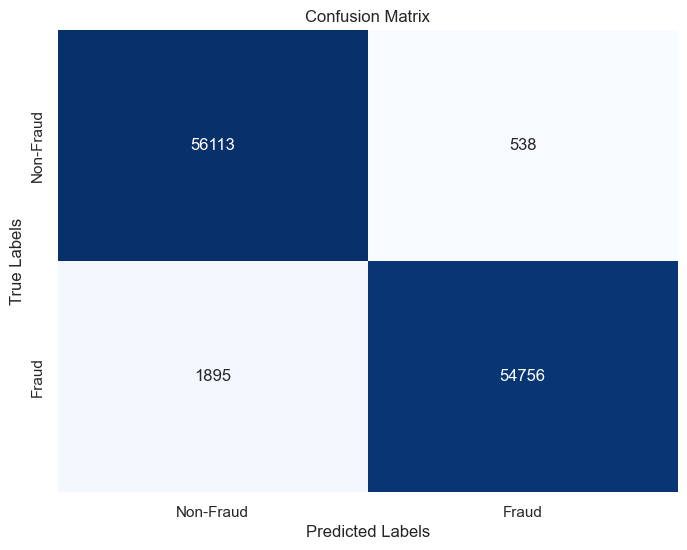

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)


# Predict on the validation set
y_val_pred = model.predict(X_val)


# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)


print("preformance on validation set")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")




# Predict on the test set
y_test_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("preformance on test set")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()




Random Forest - Validation Set Metrics:
Accuracy: 0.9998
Precision: 0.9997
Recall: 1.0000
F1 Score: 0.9998
Random Forest - Test Set Metrics:
Accuracy: 0.9999
Precision: 0.9998
Recall: 1.0000
F1 Score: 0.9999


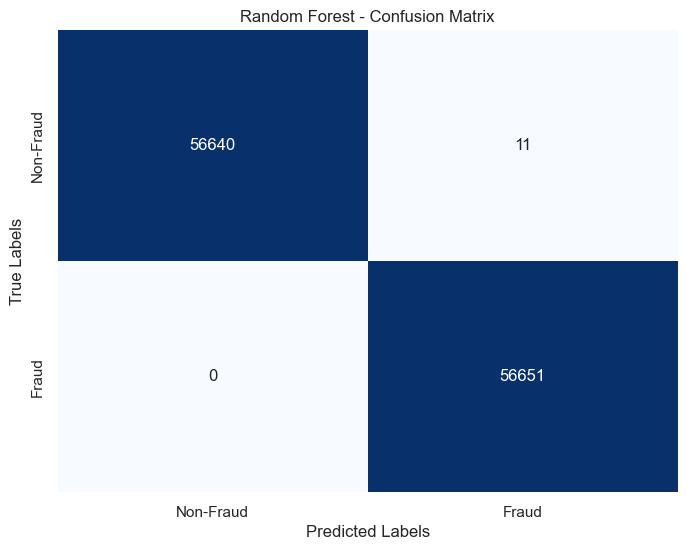

In [112]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_rf = rf_model.predict(X_val)

# Calculate evaluation metrics for the validation set
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)


print(f"Random Forest - Validation Set Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")


# Predict on the test set
y_test_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for the test set
accuracy_rf_test = accuracy_score(y_test, y_test_pred_rf)
precision_rf_test = precision_score(y_test, y_test_pred_rf)
recall_rf_test = recall_score(y_test, y_test_pred_rf)
f1_rf_test = f1_score(y_test, y_test_pred_rf)


print(f"Random Forest - Test Set Metrics:")
print(f"Accuracy: {accuracy_rf_test:.4f}")
print(f"Precision: {precision_rf_test:.4f}")
print(f"Recall: {recall_rf_test:.4f}")
print(f"F1 Score: {f1_rf_test:.4f}")


# Calculate the confusion matrix for the test set
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Random Forest - Confusion Matrix')
plt.show()



Gradient Boosting - Validation Set Metrics:
Accuracy: 0.9859
Precision: 0.9935
Recall: 0.9782
F1 Score: 0.9858
Gradient Boosting - Test Set Metrics:
Accuracy: 0.9865
Precision: 0.9934
Recall: 0.9795
F1 Score: 0.9864


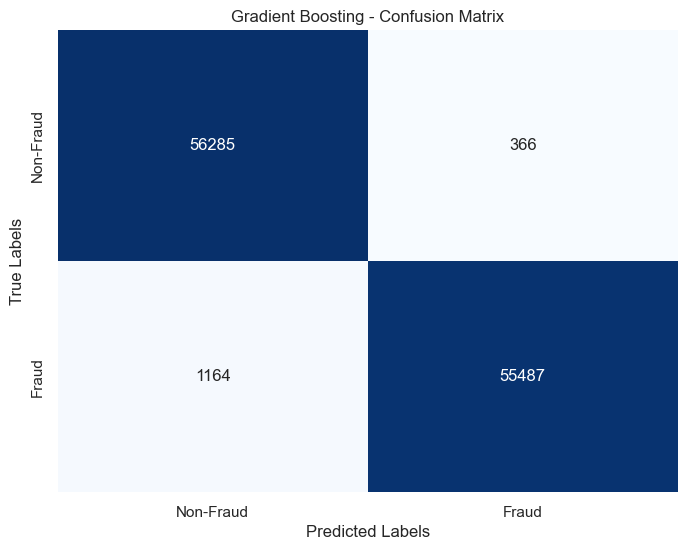

In [114]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the Gradient Boosting model
gb_model.fit(X_train, y_train)

# Predict on the validation set
y_val_pred_gb = gb_model.predict(X_val)

# Calculate evaluation metrics for the validation set
accuracy_gb = accuracy_score(y_val, y_val_pred_gb)
precision_gb = precision_score(y_val, y_val_pred_gb)
recall_gb = recall_score(y_val, y_val_pred_gb)
f1_gb = f1_score(y_val, y_val_pred_gb)

print(f"Gradient Boosting - Validation Set Metrics:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1 Score: {f1_gb:.4f}")

# Predict on the test set
y_test_pred_gb = gb_model.predict(X_test)

# Calculate evaluation metrics for the test set
accuracy_gb_test = accuracy_score(y_test, y_test_pred_gb)
precision_gb_test = precision_score(y_test, y_test_pred_gb)
recall_gb_test = recall_score(y_test, y_test_pred_gb)
f1_gb_test = f1_score(y_test, y_test_pred_gb)

print(f"Gradient Boosting - Test Set Metrics:")
print(f"Accuracy: {accuracy_gb_test:.4f}")
print(f"Precision: {precision_gb_test:.4f}")
print(f"Recall: {recall_gb_test:.4f}")
print(f"F1 Score: {f1_gb_test:.4f}")

# Calculate the confusion matrix for the test set
conf_matrix_gb = confusion_matrix(y_test, y_test_pred_gb)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()


### Analysis Summary
Based on the evaluation metrics, the Random Forest model performs the best among the three models.
It has the highest accuracy, precision, recall, and F1 score on both the validation and test sets.
The confusion matrix also indicates that the Random Forest model has the least number of false positives and false negatives, making it the most reliable model for detecting fraud in this dataset.


## Project Summary: Fraud Detection in Credit Card Transactions

### Introduction
This project aims to detect fraudulent credit card transactions using machine learning techniques. The dataset used contains transactions made by credit cards in September 2013 by European cardholders. It is highly imbalanced, with only 0.17% of transactions being fraudulent.

### EDA
- **Data Loading and Overview**: The dataset was loaded and basic information was extracted, including the absence of null values and the presence of scaled features.
- **Class Distribution**: The dataset is highly imbalanced with only 0.17% fraudulent transactions.
- **Correlation Analysis**: A heatmap was generated to visualize the correlation between numerical features. No notable correlations were found between features V1-V28.
- **Temporal Analysis**: Fraudulent transactions were analyzed by the hour of the day, revealing a peak at 2:00 AM.

### Feature Engineering
- **Hour of Day**: The 'Time' column was converted to hours.
- **Fraud Aggregation**: Fraudulent transactions were aggregated by hour to identify the most frequent hour for fraud.

### Data Preprocessing
- **Handling Imbalance**: SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the dataset.
- **Feature Scaling**: Standard scaling was applied to normalize the data.

### Model Training and Evaluation
Three models were trained and evaluated:
1. **Logistic Regression**: Provided a baseline performance metric.
2. **Random Forest**: Showed the best performance with the highest accuracy, precision, recall, and F1 score.
3. **Gradient Boosting**: Also performed well but was slightly outperformed by the Random Forest model.

### Results
- **Random Forest**: Achieved the highest F1 score of 0.9999 on the test set, making it the most reliable model for detecting fraud in this dataset.
- **Evaluation Metrics**: Accuracy, precision, recall, and F1 score were calculated for all models. Confusion matrices were plotted to visualize the performance.

### Conclusion
The Random Forest model was identified as the best-performing model for fraud detection in this dataset. The project highlights the importance of handling class imbalance and the effectiveness of ensemble methods in fraud detection tasks.